In [41]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np

from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from data_preparation.data_processor import DataProcessor

# Facebook Prophet Implementation to Forecast Daily Waste Quantities

In [42]:
waste_data = pd.read_csv("../synthetic_waste_data.csv")

fetcher = DataProcessor(waste_data)

unique_waste = fetcher.waste_data['waste_type'].unique()
waste_dfs = {}

for waste in unique_waste:
    waste_dfs[waste] = fetcher.agg_quantity(waste_type=waste, by_waste_type= True).reset_index().drop(["is_Fall","is_Spring","is_Summer","is_Winter","is_weekend","is_holiday"], axis = 1)

## Training and Predicting

In [43]:
# Calculate split indices (80% train, 10% val1, 10% val2)
total_samples = waste_dfs["Municipal"].shape[0]
train_end = int(total_samples * 0.8)
val1_end = int(total_samples * 0.9)

# Store forecasts for both validation sets
waste_quantity_forecasts_val1 = {}
waste_quantity_forecasts_val2 = {}

def train_and_predict_prophet(df_train, df_test, holidays, waste_type):
    # Rename columns to match Prophet's expected format
    df_train = df_train.rename(columns={'date': 'ds', 'quantity_tons': 'y'})
    df_test = df_test.rename(columns={'date': 'ds', 'quantity_tons': 'y'})
    
    # Create Prophet model without default seasonalities
    model = Prophet(holidays=holidays, yearly_seasonality=False, weekly_seasonality=False, growth = "flat")

    # Add custom seasonalities based on waste type
    if waste_type == 'Municipal':
        model.add_seasonality(name='annual', period=365.25, fourier_order=10)
        model.add_seasonality(name='weekly', period=7, fourier_order=6)
        model.add_seasonality(name='semi_weekly', period=3.5, fourier_order=3)

    elif waste_type == 'Industrial':
        model.add_seasonality(name='industrial', period=2.33, fourier_order=3)
        model.add_seasonality(name='weekly', period=7, fourier_order=6)

    elif waste_type == 'Organic':
        model.add_seasonality(name='annual', period=365.25, fourier_order=10)
        model.add_seasonality(name='weekly', period=7, fourier_order=6)
        model.add_seasonality(name='semi_weekly', period=3.5, fourier_order=3)

    elif waste_type == 'Construction':
        model.add_seasonality(name='annual', period=365.25, fourier_order=10)
        model.add_seasonality(name='semi_weekly', period=3.5, fourier_order=3)

    elif waste_type == 'Commercial':
        model.add_seasonality(name='annual', period=365.25, fourier_order=10)
        model.add_seasonality(name='weekly', period=7, fourier_order=6)
        model.add_seasonality(name='semi_weekly', period=3.5, fourier_order=3)

    # Fit the model
    model.fit(df_train)
    
    # Create future dataframe
    future_dates = model.make_future_dataframe(periods=len(df_test))
    
    # Predict
    forecast = model.predict(future_dates)
    
    return model, forecast


# Define the custom holidays
holidays_base = [
    '2022-01-01', '2022-01-02', '2022-01-03', '2022-01-04',  # New Year
        '2022-12-23', '2022-12-24', '2022-12-25', '2022-12-26', '2022-12-27', '2022-12-28',  # Christmas time
        '2023-01-01','2023-01-02', '2023-01-03', '2023-01-04',  # New Year
        '2023-12-23', '2023-12-24', '2023-12-25', '2023-12-26', '2023-12-27', '2023-12-28',  # Christmas time
        '2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',  # New Year
        '2024-12-23', '2024-12-24', '2024-12-25', '2024-12-26', '2024-12-27', '2024-12-28',  # Christmas time
]

# Create a holidays dataframe
holidays = pd.DataFrame({'ds': pd.to_datetime(holidays_base), 'holiday': 'custom_holiday'})


for waste, df in waste_dfs.items():
    # Split the data
    train_data = df[:train_end]
    val1_data = df[train_end:val1_end]
    val2_data = df[val1_end:]
    
    # Train and predict for Validation Set 1
    model_val1, forecast_val1 = train_and_predict_prophet(train_data, val1_data, holidays, waste)
    waste_quantity_forecasts_val1[waste] = forecast_val1
    
    # Train and predict for Validation Set 2 (using train + val1 as new training)
    train_val2_data = pd.concat([train_data, val1_data])
    model_val2, forecast_val2 = train_and_predict_prophet(train_val2_data, val2_data, holidays, waste)
    waste_quantity_forecasts_val2[waste] = forecast_val2

14:12:59 - cmdstanpy - INFO - Chain [1] start processing
14:12:59 - cmdstanpy - INFO - Chain [1] done processing
14:13:00 - cmdstanpy - INFO - Chain [1] start processing
14:13:00 - cmdstanpy - INFO - Chain [1] done processing
14:13:01 - cmdstanpy - INFO - Chain [1] start processing
14:13:01 - cmdstanpy - INFO - Chain [1] done processing
14:13:01 - cmdstanpy - INFO - Chain [1] start processing
14:13:01 - cmdstanpy - INFO - Chain [1] done processing
14:13:02 - cmdstanpy - INFO - Chain [1] start processing
14:13:02 - cmdstanpy - INFO - Chain [1] done processing
14:13:03 - cmdstanpy - INFO - Chain [1] start processing
14:13:03 - cmdstanpy - INFO - Chain [1] done processing
14:13:03 - cmdstanpy - INFO - Chain [1] start processing
14:13:04 - cmdstanpy - INFO - Chain [1] done processing
14:13:04 - cmdstanpy - INFO - Chain [1] start processing
14:13:04 - cmdstanpy - INFO - Chain [1] done processing
14:13:05 - cmdstanpy - INFO - Chain [1] start processing
14:13:05 - cmdstanpy - INFO - Chain [1]

## Calculating Error Metrics

In [44]:
waste_quantity_preds_prophetval1 = {}
waste_quantity_preds_prophetval2 = {}

print("\n" + "="*50)
print("Test Set 1 Evaluation")
print("="*50)
for waste, forecast in waste_quantity_forecasts_val1.items():

    # Get the actual values for the test period
    test_actual = waste_dfs[waste]['quantity_tons'].values[train_end:val1_end]
    
    # Get the predicted values for the test period
    test_predicted = forecast['yhat'].values[train_end:val1_end]
    waste_quantity_preds_prophetval1[waste] = test_predicted

    # Get the dates for the test period
    test_dates = forecast['ds'].iloc[train_end:val1_end].to_numpy()
    rmse = root_mean_squared_error(test_actual, test_predicted)
    mae = mean_absolute_error(test_actual, test_predicted)
    
    print(f"\n{waste}:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    
    # Create a new figure and plot the actual and predicted values for the test set
    #plt.figure(figsize=(10, 6))
    #plt.plot(test_dates[:], test_actual[:], label='Actual', color = "blue")
    #plt.plot(test_dates[:len(test_actual)-1], test_predicted[:len(test_actual)-1], label='Predicted', color = "red", linestyle = "dashed")
    #plt.xlabel('Date')
    #plt.ylabel('Quantity (tons)')
    #plt.title(f"actual vs predicted for {waste}")
    #plt.legend()
    
predictions_df = pd.DataFrame(waste_quantity_preds_prophetval1)
predictions_df.to_csv('prophet_preds.csv', index=False)


print("\n" + "="*50)
print("Test Set 2 Evaluation")
print("="*50)

for waste, forecast in waste_quantity_forecasts_val2.items():

    # Get the actual values for the test period
    test_actual = waste_dfs[waste]['quantity_tons'].values[val1_end:]
    
    # Get the predicted values for the test period
    test_predicted = forecast['yhat'].values[val1_end:]
    waste_quantity_preds_prophetval2[waste] = test_predicted

    # Get the dates for the test period
    test_dates = forecast['ds'].iloc[val1_end:].to_numpy()
    rmse = root_mean_squared_error(test_actual, test_predicted)
    mae = mean_absolute_error(test_actual, test_predicted)
    
    print(f"\n{waste}:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    
    # Create a new figure and plot the actual and predicted values for the test set
    #plt.figure(figsize=(10, 6))
    #plt.plot(test_dates[:], test_actual[:], label='Actual', color = "blue")
    #plt.plot(test_dates[:len(test_actual)-1], test_predicted[:len(test_actual)-1], label='Predicted', color = "red", linestyle = "dashed")
    ##plt.xlabel('Date')
    ##plt.ylabel('Quantity (tons)')
    #plt.title(f"actual vs predicted for {waste}")
    #plt.legend()

predictions_df_1 = pd.DataFrame(waste_quantity_preds_prophetval1)
predictions_df_1.to_csv('prophet_preds_1.csv', index=False)

predictions_df_2 = pd.DataFrame(waste_quantity_preds_prophetval2)
predictions_df_2.to_csv('prophet_preds_2.csv', index=False)


Test Set 1 Evaluation

Municipal:
RMSE: 49.79
MAE: 38.96

Industrial:
RMSE: 41.16
MAE: 34.19

Organic:
RMSE: 42.34
MAE: 32.29

Construction:
RMSE: 37.19
MAE: 29.47

Commercial:
RMSE: 29.89
MAE: 23.96

Test Set 2 Evaluation

Municipal:
RMSE: 49.32
MAE: 36.38

Industrial:
RMSE: 39.79
MAE: 30.75

Organic:
RMSE: 26.81
MAE: 19.76

Construction:
RMSE: 22.27
MAE: 16.81

Commercial:
RMSE: 38.35
MAE: 29.35


## Creating Plots for Residual Analysis

In [45]:
def create_diagnostic_plots(waste_quantity_preds, waste_dfs, train_end, val_end):
    num_wastes = len(waste_quantity_preds)
    
    
    # For residuals and ACF: 2 columns, enough rows
    resid_rows = 3
    fig_resid, axs_resid = plt.subplots(resid_rows, 2, figsize=(18, 5*resid_rows))
    fig_acf, axs_acf = plt.subplots(resid_rows, 2, figsize=(18, 5*resid_rows))
    
    # For combined histogram + QQ: 1 column, num_wastes rows
    fig_hist_qq, axs_hist_qq = plt.subplots(num_wastes, 2, figsize=(18, 5*num_wastes))
    
    # Flatten axes arrays for easy iteration
    axs_resid = axs_resid.flatten() if num_wastes > 1 else [axs_resid]
    axs_acf = axs_acf.flatten() if num_wastes > 1 else [axs_acf]
    
    for idx, (waste, forecast) in enumerate(waste_quantity_preds.items()):
        # Get the actual values for the test period
        if val_end == None:
            test_actual = waste_dfs[waste]['quantity_tons'].values[train_end:]
            residuals = test_actual - forecast
            test_dates = waste_dfs[waste]['date'].iloc[train_end:].to_numpy()
        else: 
            test_actual = waste_dfs[waste]['quantity_tons'].values[train_end:val_end]
            residuals = test_actual - forecast
            test_dates = waste_dfs[waste]['date'].iloc[train_end:val_end].to_numpy()
            
        # 1. Residuals plot
        ax = axs_resid[idx]
        ax.plot(test_dates, residuals, color='black', label='Residuals')
        ax.axhline(y=0, color='black', linestyle='--')
        ax.set_xlabel('Date')
        ax.set_ylabel('Residuals')
        ax.set_title(f"{waste}")
        
        # 2. Combined Histogram + QQ plot
        # Histogram on left (axs_hist_qq[idx, 0])
        ax_hist = axs_hist_qq[idx, 0]
        ax_hist.hist(residuals, bins=10, edgecolor = "white")
        ax_hist.set_title(f"{waste}")
        ax_hist.set_xlabel('Residual Value')
        ax_hist.set_ylabel('Density')
        
        # QQ plot on right (axs_hist_qq[idx, 1])
        ax_qq = axs_hist_qq[idx, 1]
        sm.qqplot(residuals, line='45', fit=True, ax=ax_qq)
        ax_qq.set_title(f"{waste}")
        
        # 3. ACF plot
        ax = axs_acf[idx]
        plot_acf(residuals, ax=ax, lags=61)
        ax.set_title(f"{waste}")
    
    # Hide any empty subplots
    for idx in range(num_wastes, resid_rows*2):
        axs_resid[idx].axis('off')
        axs_acf[idx].axis('off')
    
    # Adjust layout
    fig_resid.tight_layout()
    fig_hist_qq.tight_layout()
    fig_acf.tight_layout()
    
    return fig_resid, fig_hist_qq, fig_acf

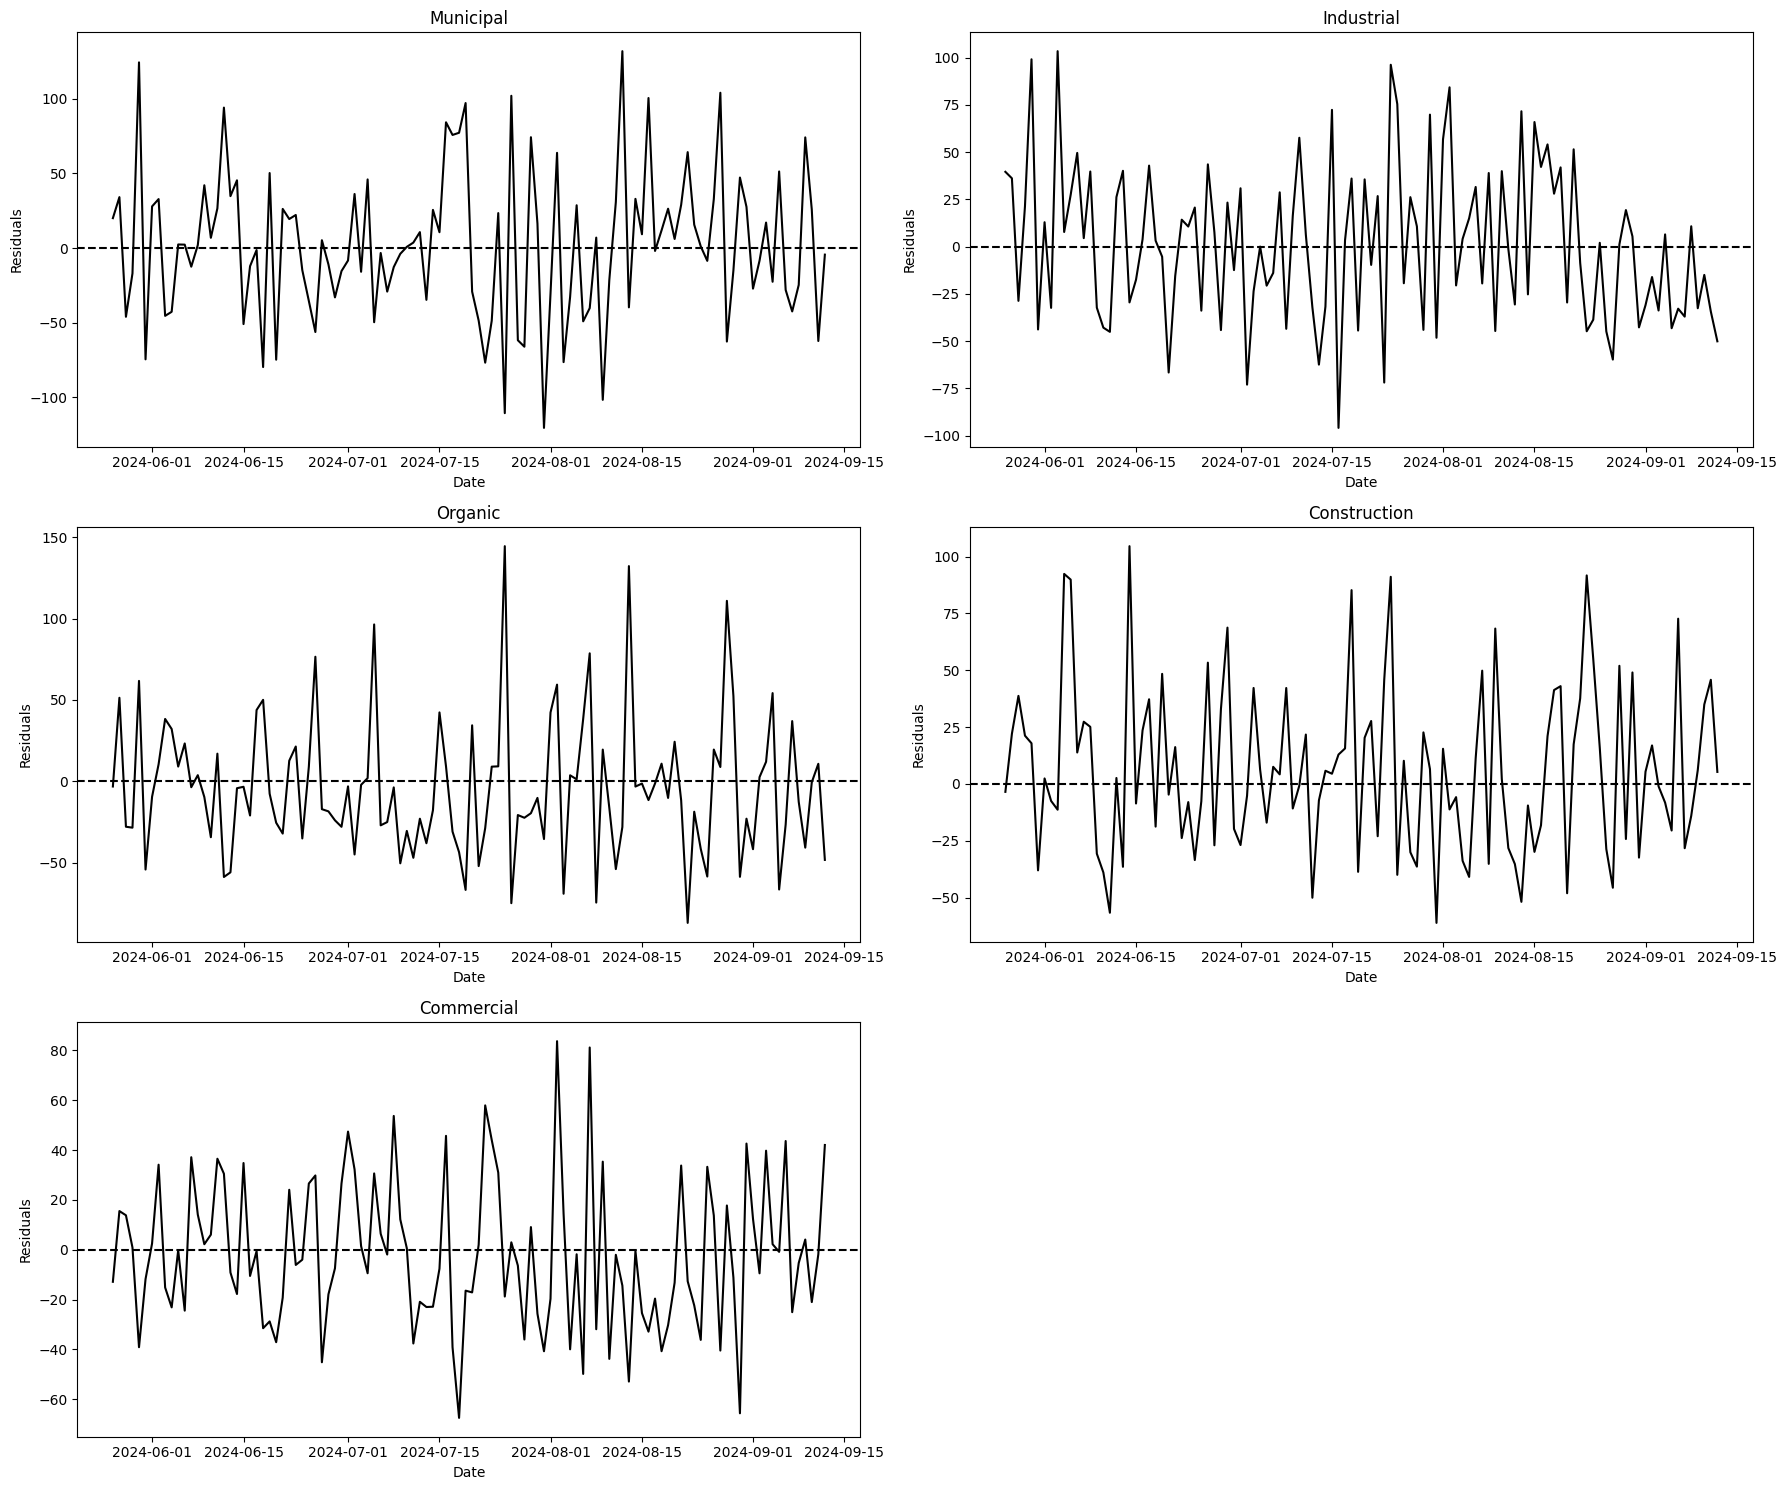

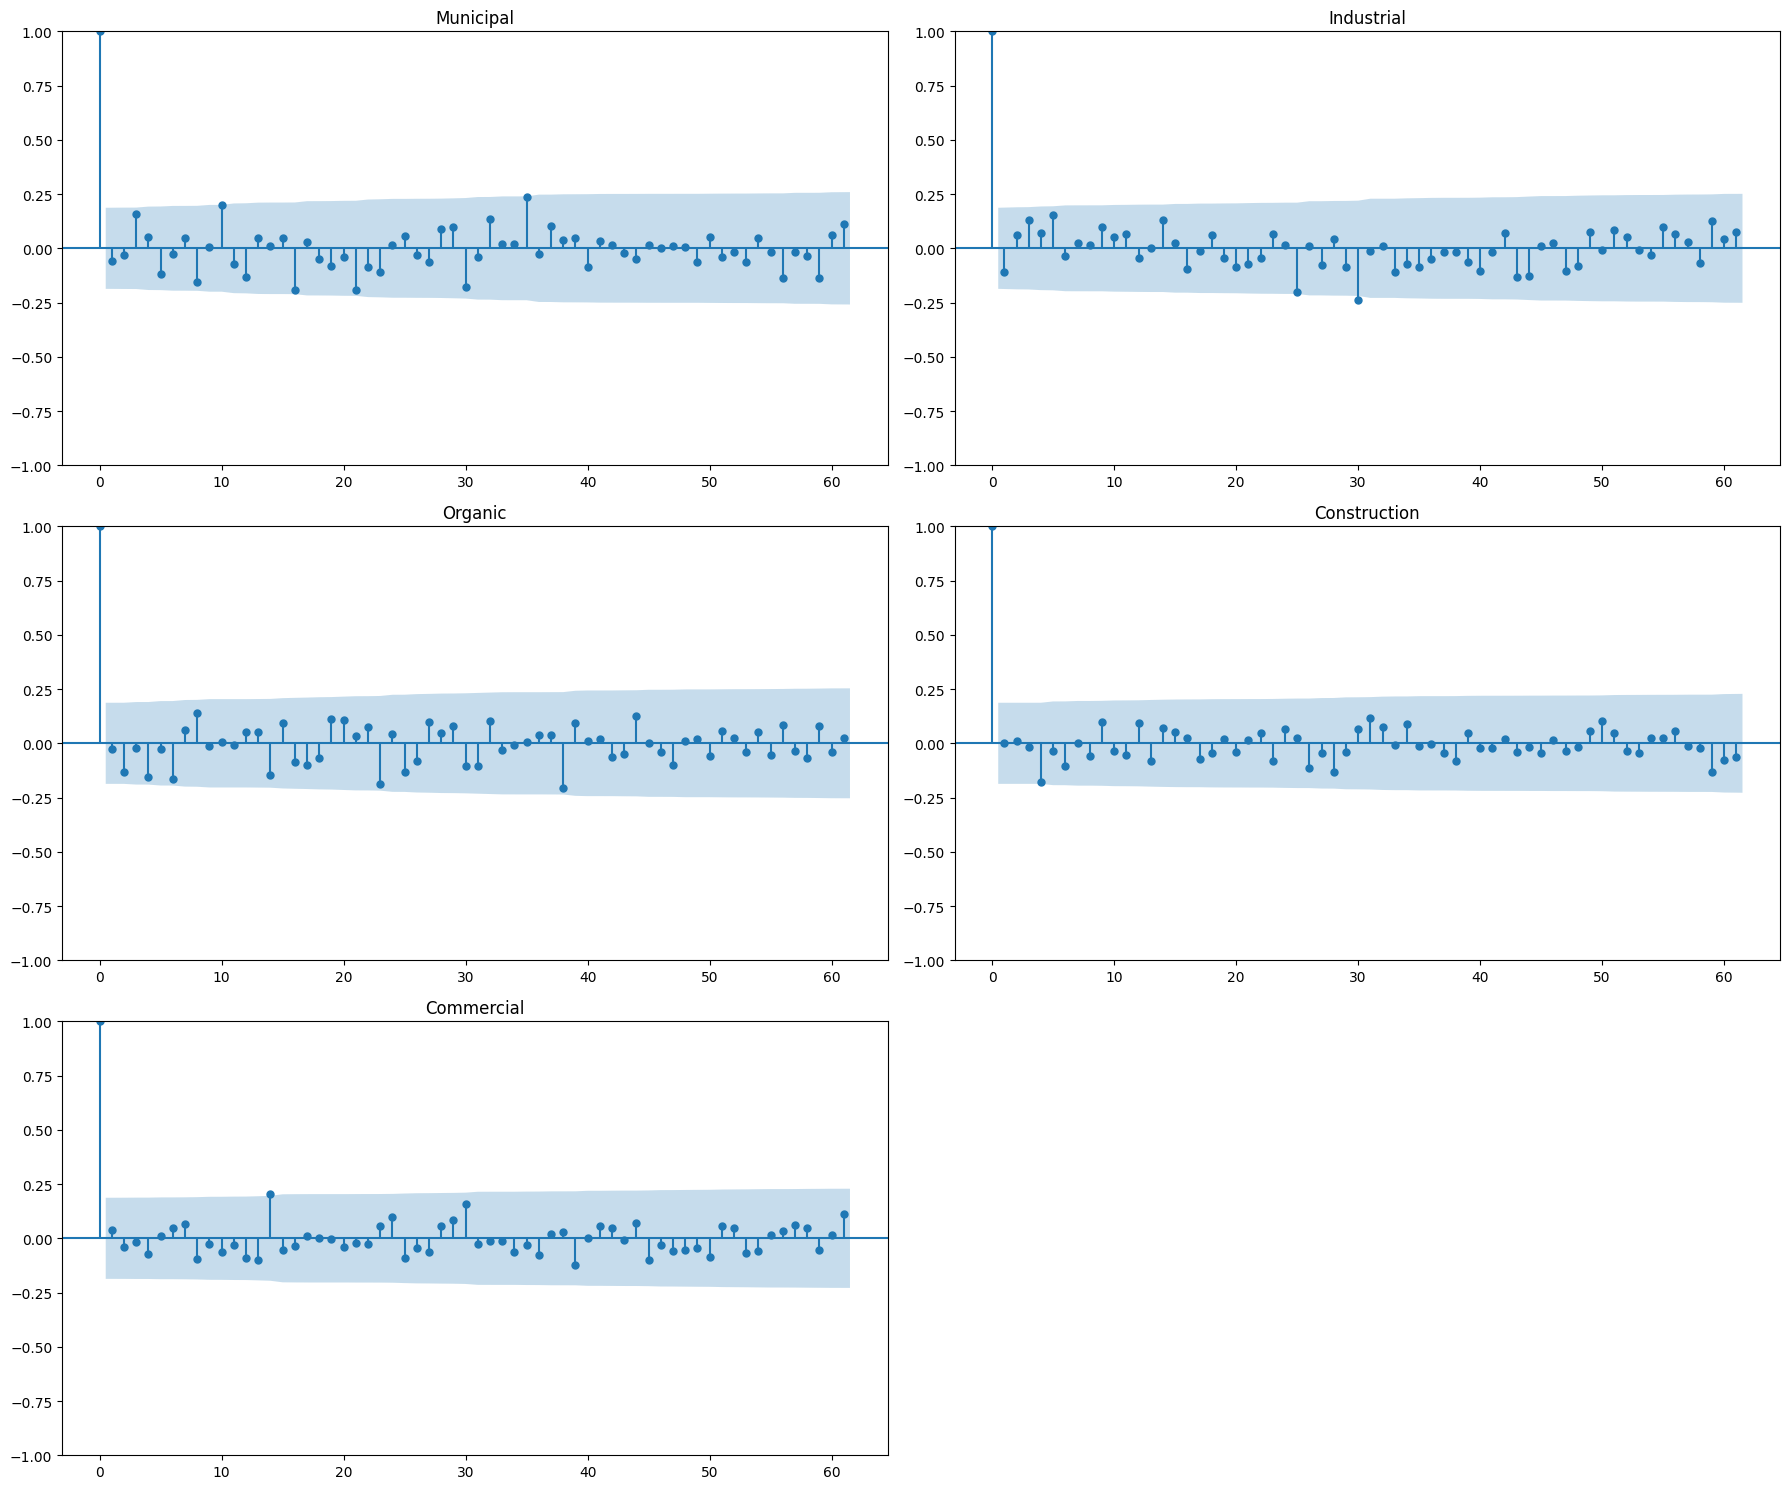

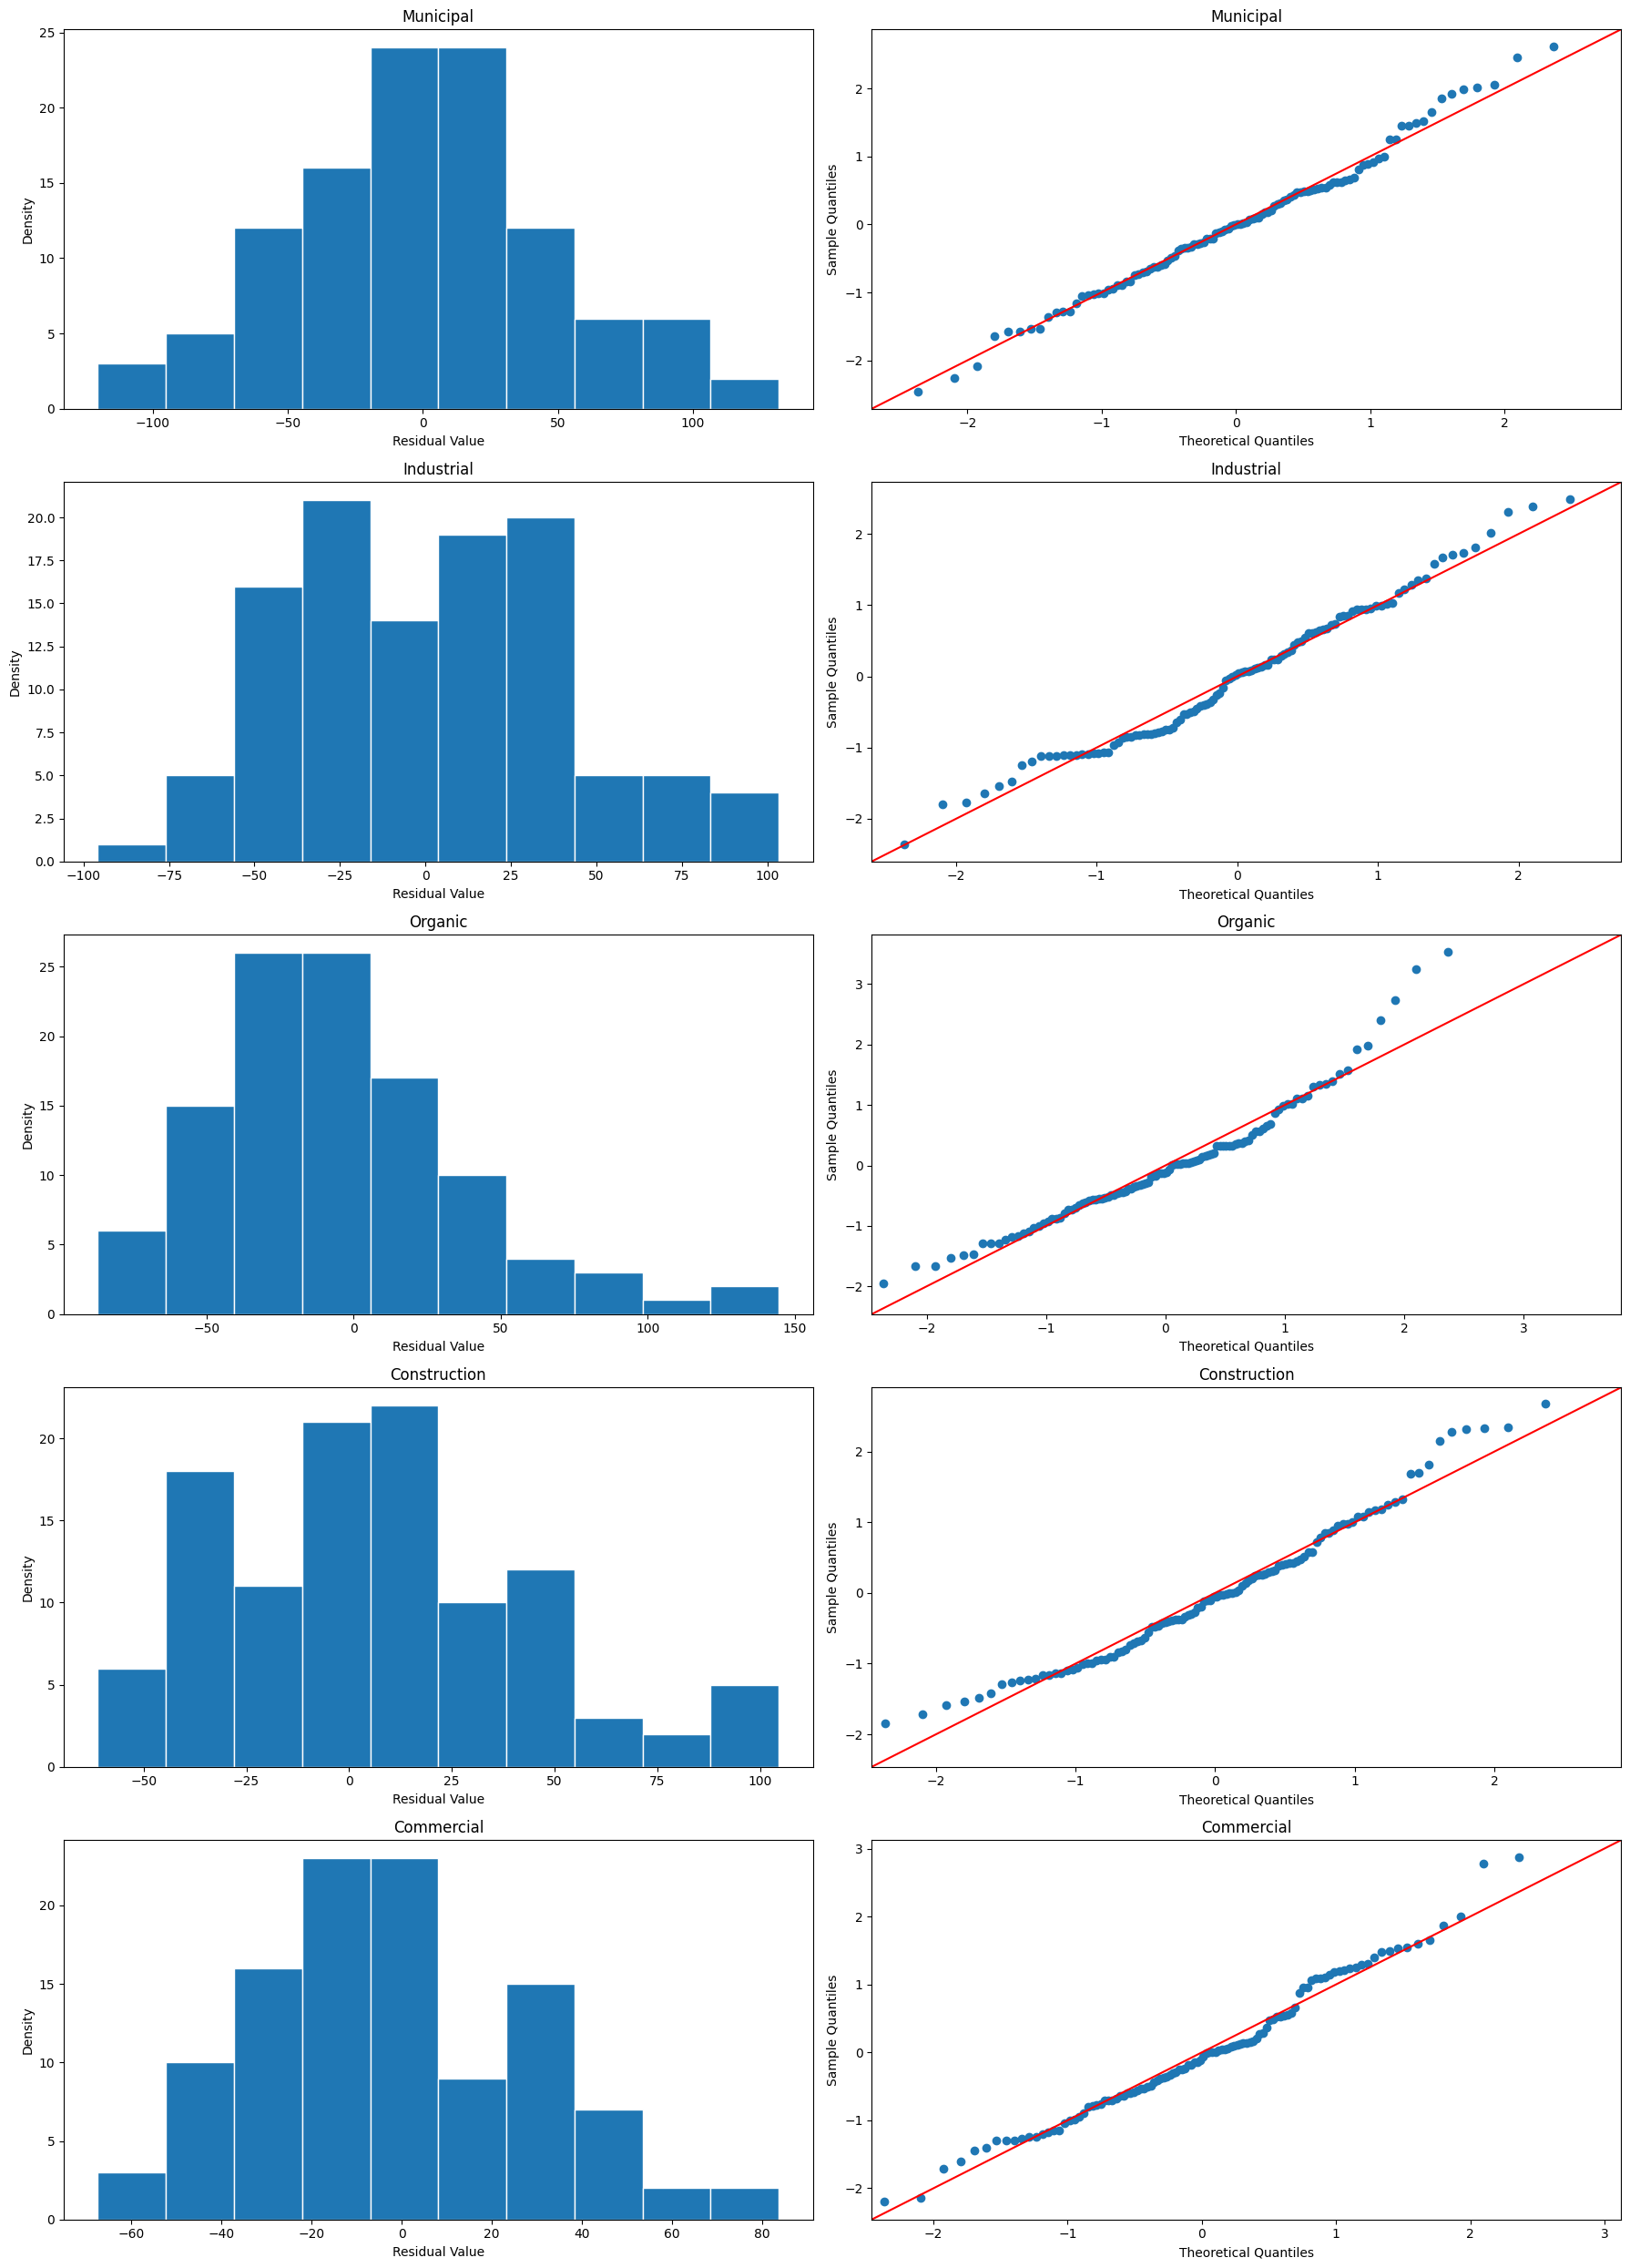

In [46]:
fig_resid_val1, fig_qq_val1, fig_acf_val1 = create_diagnostic_plots(
    waste_quantity_preds_prophetval1, 
    waste_dfs, 
    train_end, 
    val1_end, 
)

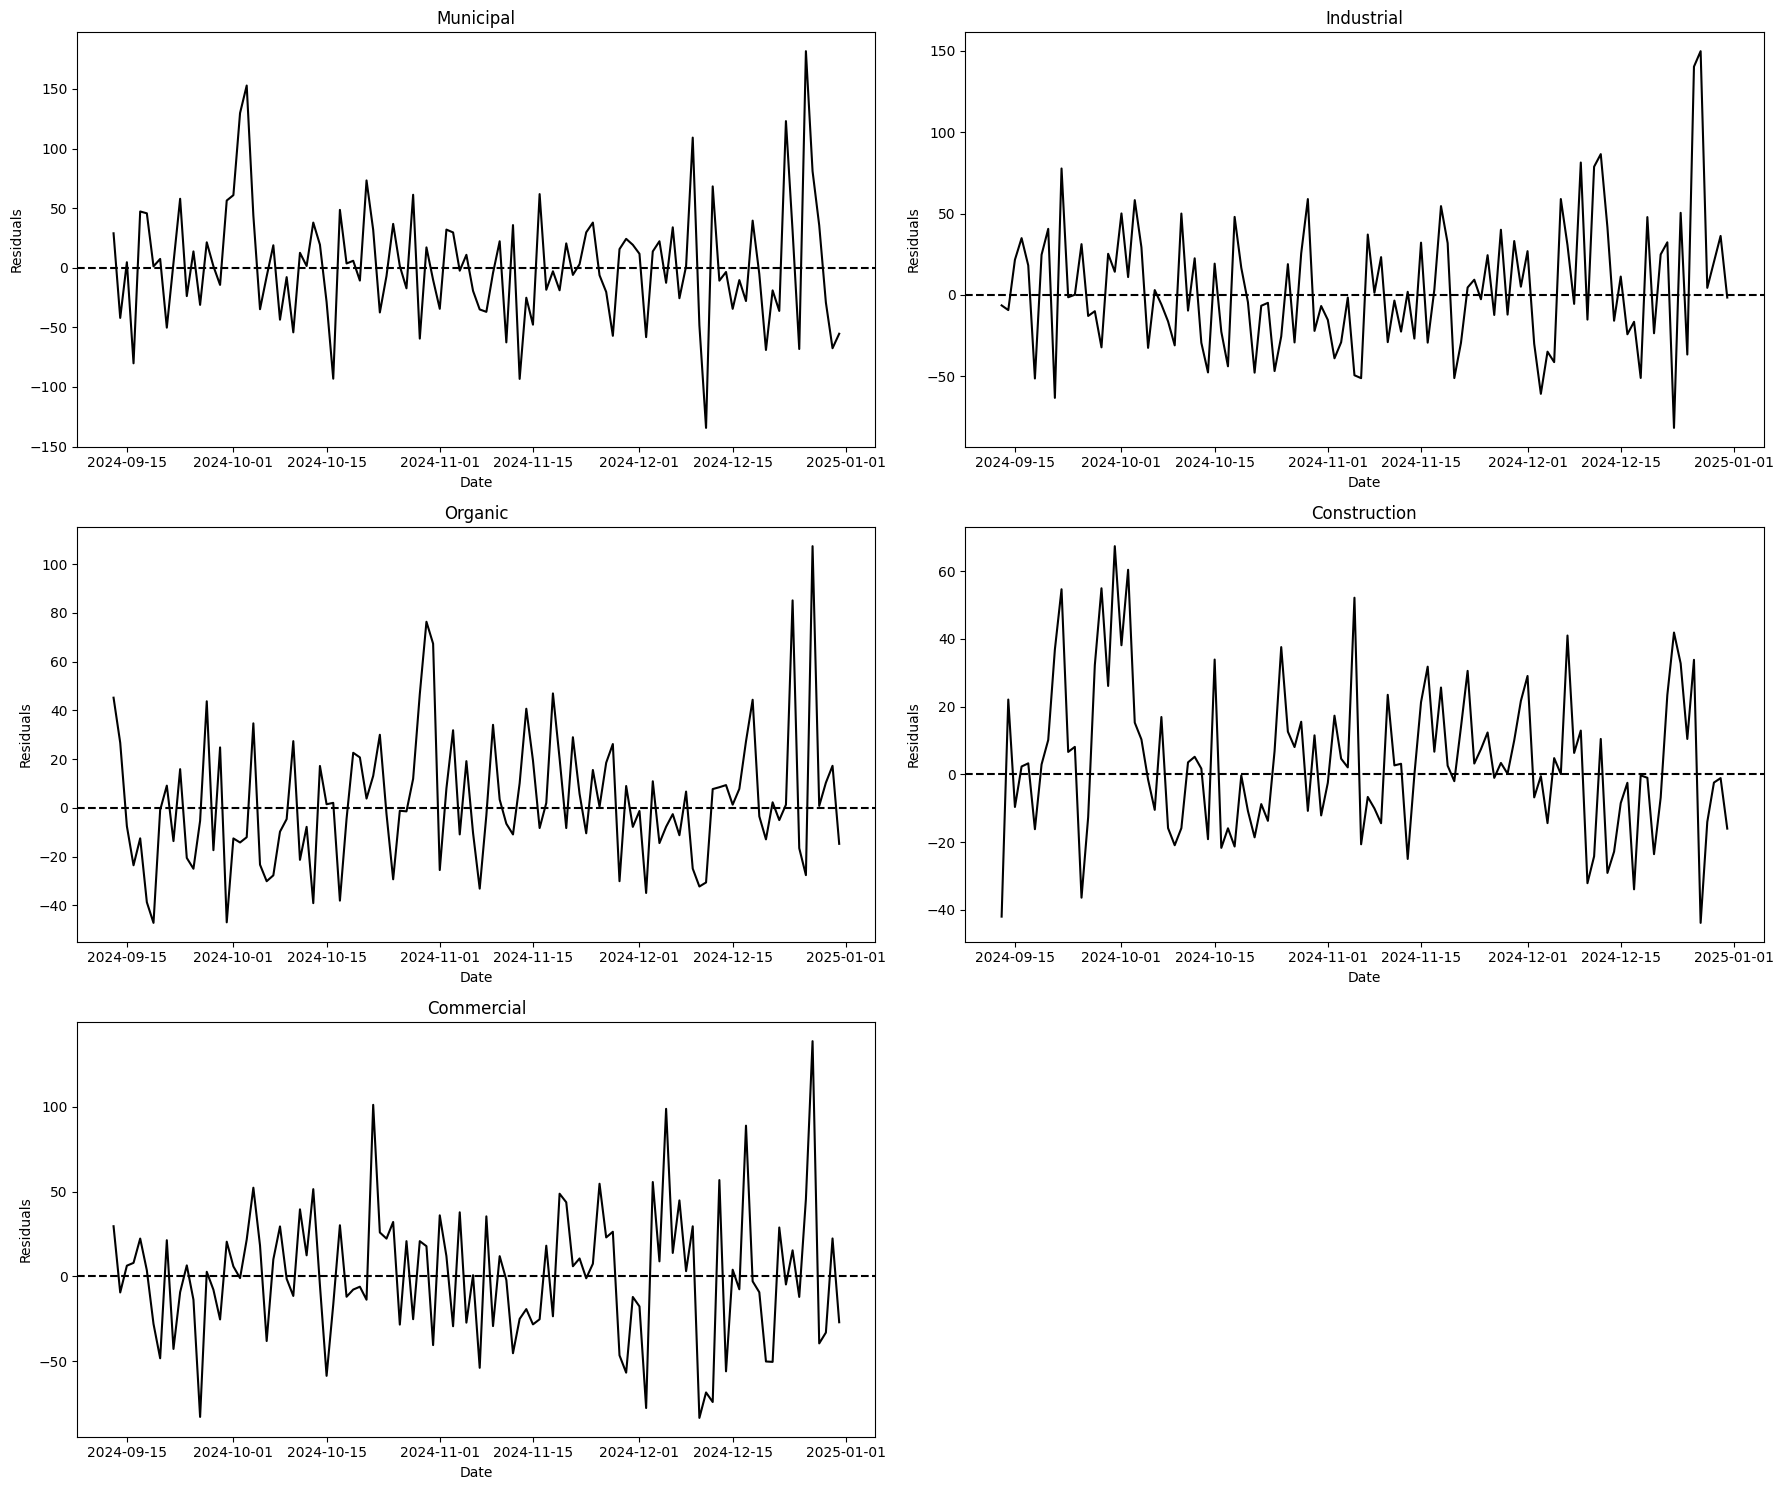

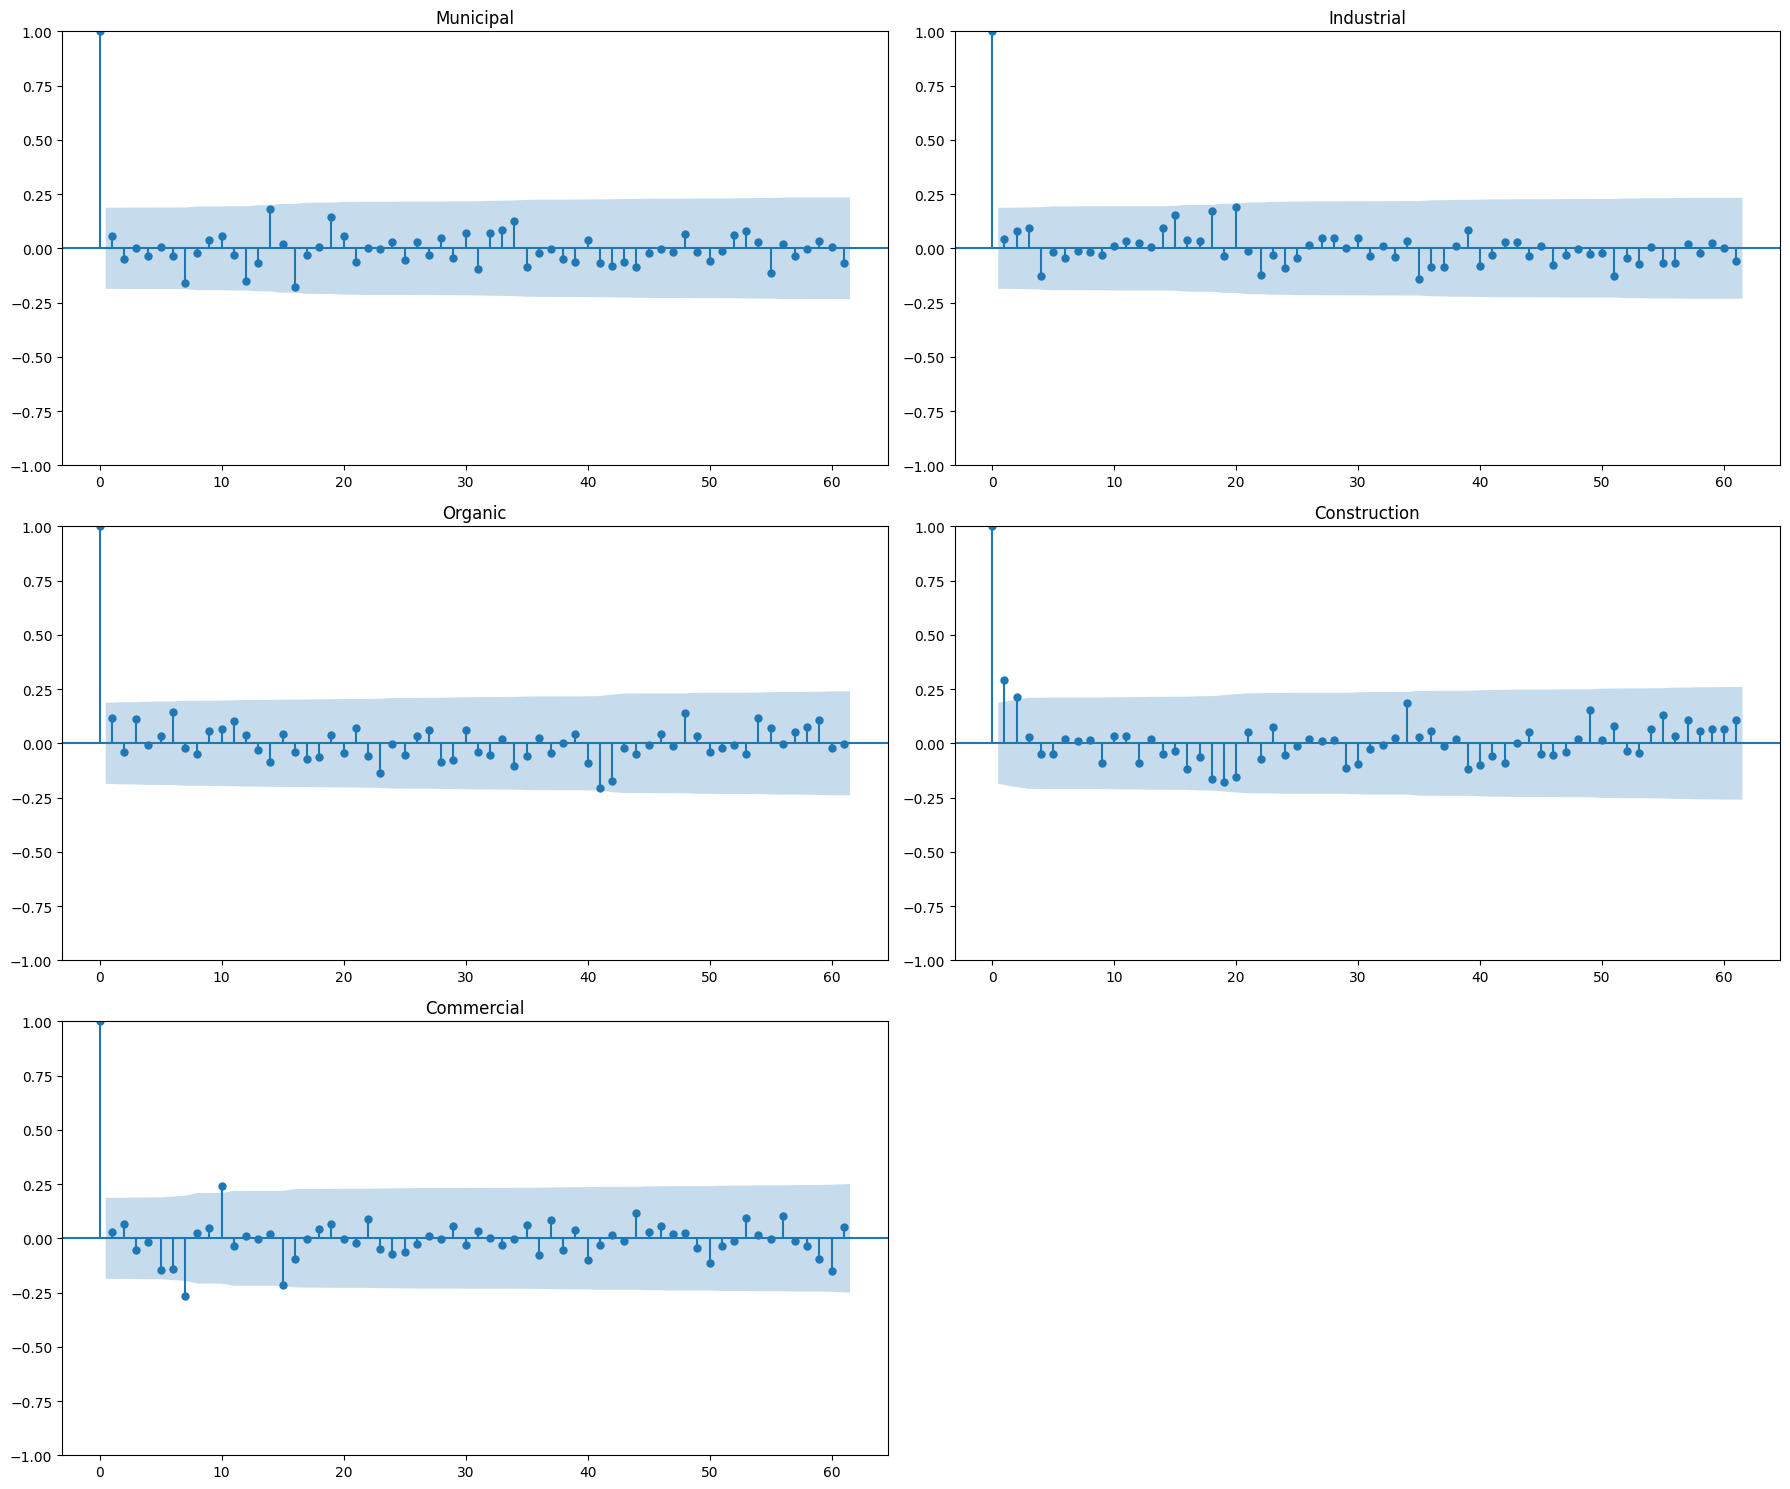

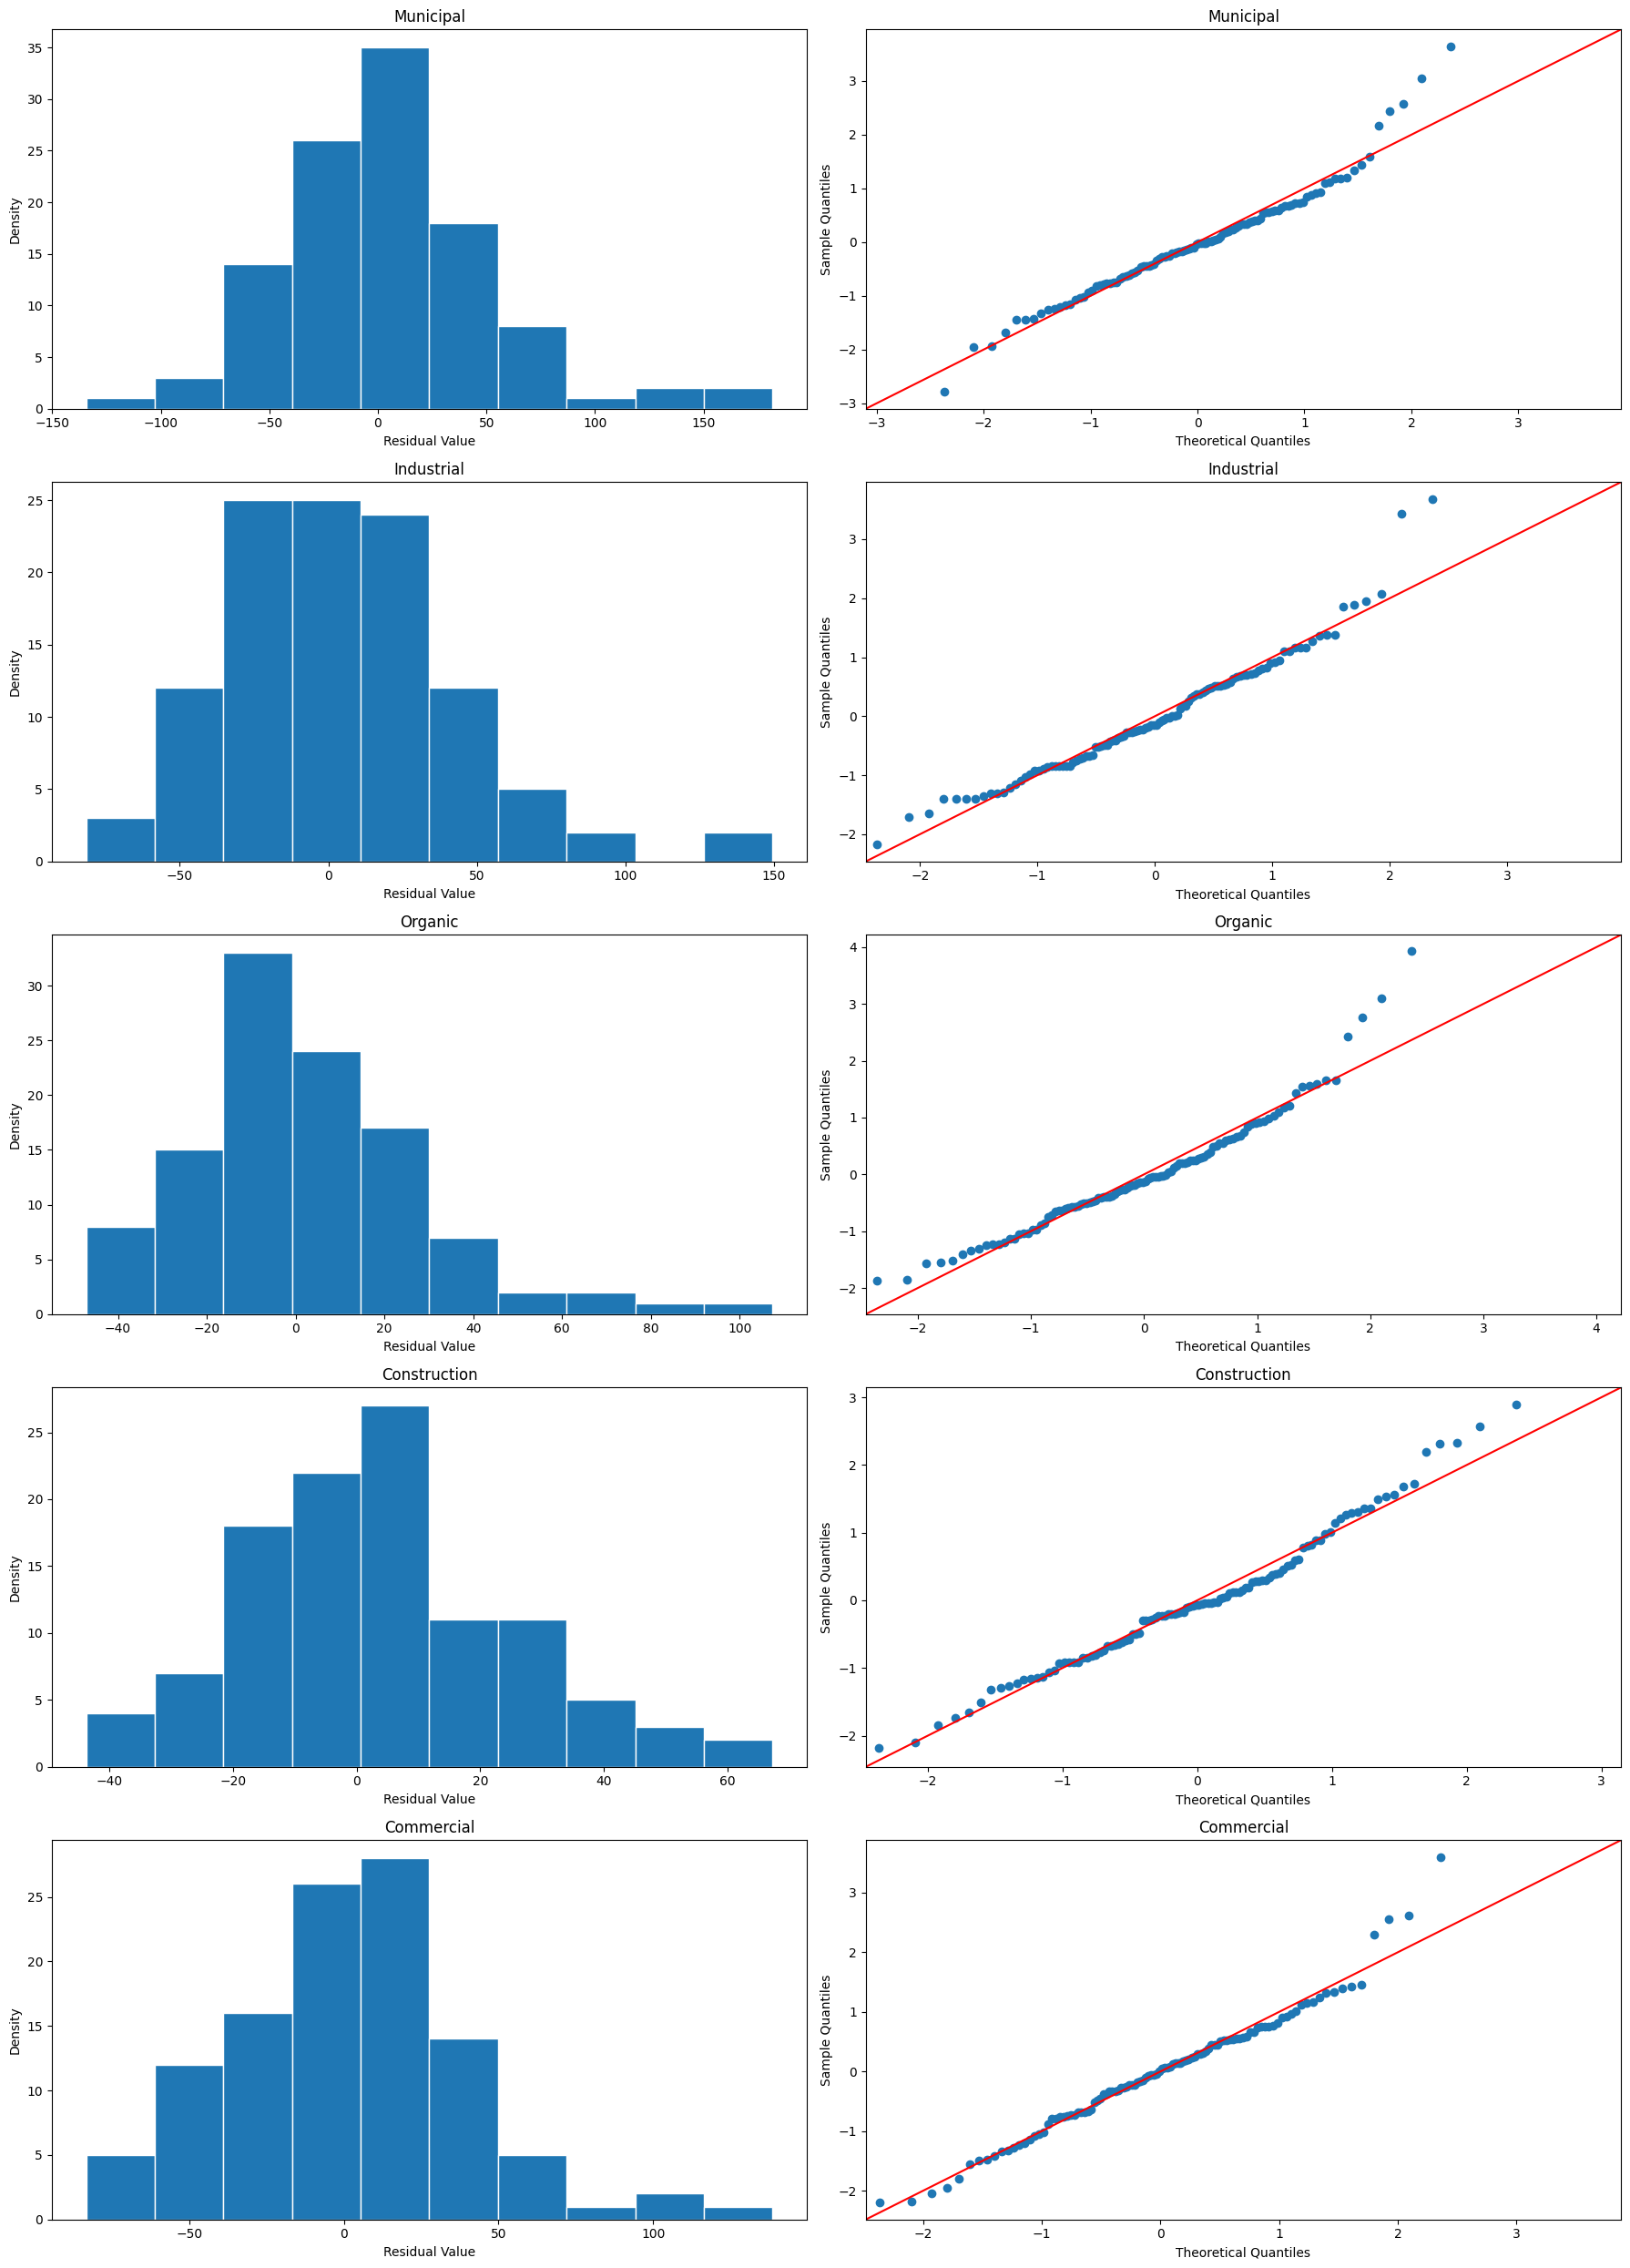

In [47]:
# Generate plots for val2
fig_resid_val2, fig_qq_val2, fig_acf_val2 = create_diagnostic_plots(
    waste_quantity_preds_prophetval2, 
    waste_dfs, 
    val1_end, 
    None
)

## Ljung-Box Test for Residual Autocorrelation

In [48]:
print("="*50)
print("Test Set 1")
print("="*50)

for waste, forecast in waste_quantity_preds_prophetval1.items():

    # Get the actual values for the test period
    test_actual = waste_dfs[waste]['quantity_tons'].values[train_end:val1_end]
    
    # Calculate the residuals
    residuals = test_actual - forecast

    # Ljung-Box Test
    lb_test = acorr_ljungbox(residuals, lags=[21], return_df=True)
    print(f"\n{waste}")
    print(lb_test)


print("\n" + "="*50)
print("Test Set 2")
print("="*50)

for waste, forecast in waste_quantity_preds_prophetval2.items():
    
    # Get the actual values for the test period
    test_actual = waste_dfs[waste]['quantity_tons'].values[val1_end:]
    
    # Calculate the residuals
    residuals = test_actual - forecast
    
    # Ljung-Box Test
    lb_test = acorr_ljungbox(residuals, lags=[21], return_df=True)
    print(f"\n{waste}")
    print(lb_test)

Test Set 1

Municipal
      lb_stat  lb_pvalue
21  28.220815   0.133999

Industrial
      lb_stat  lb_pvalue
21  15.635624   0.789762

Organic
      lb_stat  lb_pvalue
21  21.835953   0.409016

Construction
      lb_stat  lb_pvalue
21  11.687718   0.947667

Commercial
      lb_stat  lb_pvalue
21  12.063597   0.937885

Test Set 2

Municipal
      lb_stat  lb_pvalue
21  20.470966    0.49163

Industrial
      lb_stat  lb_pvalue
21  18.146234   0.639732

Organic
     lb_stat  lb_pvalue
21  12.37638   0.928895

Construction
      lb_stat  lb_pvalue
21  32.184679   0.056077

Commercial
      lb_stat  lb_pvalue
21  30.463927   0.083054
